# Google Drive Mount

In [3]:
import sys

# Install required packages
!pip install -q numpy pandas matplotlib seaborn scikit-learn pillow-heif
!pip install pytorch-metric-learning

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define paths for Google Drive
vgg_path = '/content/drive/MyDrive/VGG'
arcface_path = '/content/drive/MyDrive/Arcface'

print("Google Drive mounted successfully!")
print(f"VGG path: {vgg_path}")
print(f"ArcFace path: {arcface_path}")

Mounted at /content/drive
Google Drive mounted successfully!
VGG path: /content/drive/MyDrive/VGG
ArcFace path: /content/drive/MyDrive/Arcface


# Import Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.metrics.pairwise import euclidean_distances, cosine_distances
import warnings
warnings.filterwarnings('ignore')

# Load Data (Features and Labels)

In [5]:
import os

# VGG Features and Labels
vgg_gallery_features = np.load(os.path.join(vgg_path, 'vgg_gallery_features.npy'))
vgg_gallery_labels = np.load(os.path.join(vgg_path, 'vgg_gallery_labels.npy'), allow_pickle=True)
vgg_gallery_filenames = np.load(os.path.join(vgg_path, 'vgg_gallery_filenames.npy'), allow_pickle=True)

vgg_probe_features = np.load(os.path.join(vgg_path, 'vgg_probe_features.npy'))
vgg_probe_labels = np.load(os.path.join(vgg_path, 'vgg_probe_labels.npy'), allow_pickle=True)
vgg_probe_filenames = np.load(os.path.join(vgg_path, 'vgg_probe_filenames.npy'), allow_pickle=True)

# ArcFace Features and Labels
arcface_gallery_features = np.load(os.path.join(arcface_path, 'arcface_gallery_features.npy'))
arcface_gallery_labels = np.load(os.path.join(arcface_path, 'arcface_gallery_labels.npy'), allow_pickle=True)

arcface_probe_features = np.load(os.path.join(arcface_path, 'arcface_probe_features.npy'))
arcface_probe_labels = np.load(os.path.join(arcface_path, 'arcface_probe_labels.npy'), allow_pickle=True)
arcface_probe_filenames = np.load(os.path.join(arcface_path, 'arcface_probe_filenames.npy'), allow_pickle=True)

print("Data Loaded:")
print(f"\nVGG Gallery: features {vgg_gallery_features.shape}, probe {vgg_probe_features.shape}")
print(f"ArcFace Gallery: features {arcface_gallery_features.shape}, probe {arcface_probe_features.shape}")
print(f"\nGallery images (identity baseline): {len(np.unique(vgg_gallery_labels))}")
print(f"Probe set (with variations): {len(vgg_probe_features)} images")


Data Loaded:

VGG Gallery: features (134, 4096), probe (588, 4096)
ArcFace Gallery: features (133, 512), probe (581, 512)

Gallery images (identity baseline): 11
Probe set (with variations): 588 images


# Extract Conditions for condition classification

In [6]:
def extract_condition_from_filename(filename):
    filename_lower = str(filename).lower()

    # Mapping of keywords to condition types with severity levels
    conditions = {
        "lighting": [
            ("extra bright", 3),
            ("very bright", 3),
            ("blue lighting", 3),
            ("purple light", 3),
            ("red lighting", 3),
            ("bright", 2),
            ("slight bright", 1),
            ("medium bright", 1),
            ("dim", 1),
            ("colored", 2)
        ],
        "blur": [
            ("super blur", 3),
            ("super blurry", 3),
            ("very blurry", 3),
            ("heavy blur", 3),
            ("medium blur", 2),
            ("medium blurry", 2),
            ("low blur", 1),
            ("light blur", 1),
            ("slight blur", 1),
            ("slight blurry", 1),
            ("even less blur", 1),
            ("even less blurry", 1),
            ("less blurry", 1),
            ("very blur", 3)
        ],
        "edit": [
            ("heavy edit", 3),
            ("strong edit", 3),
            ("medium edit", 2),
            ("light edit", 1),
            ("slight edit", 1)
        ]
    }

    detected_condition = None
    detected_severity = 1
    matched_keyword = None

    for condition_type, keywords_with_severity in conditions.items():
        for keyword, severity in keywords_with_severity:
            if keyword in filename_lower:
                detected_condition = condition_type
                detected_severity = severity
                matched_keyword = keyword
                break
        if detected_condition:
            break

    return detected_condition, detected_severity, filename_lower, matched_keyword

# Extract conditions from probe data
probe_conditions = []
probe_condition_types = []
probe_severities = []

for filename in vgg_probe_filenames:
    condition_type, severity, full_str, keyword = extract_condition_from_filename(filename)
    probe_conditions.append((condition_type, severity, full_str))
    probe_condition_types.append(condition_type if condition_type else 'unknown')
    probe_severities.append(severity)

# create df for vgg
vgg_df_probe = pd.DataFrame({
    'filename': vgg_probe_filenames,
    'condition': probe_condition_types,
    'severity': probe_severities,
    'person_id': vgg_probe_labels
})

probe_conditions = []
probe_condition_types = []
probe_severities = []

for filename in arcface_probe_filenames:
    condition_type, severity, full_str, keyword = extract_condition_from_filename(filename)
    probe_conditions.append((condition_type, severity, full_str))
    probe_condition_types.append(condition_type if condition_type else 'unknown')
    probe_severities.append(severity)

# create df for arcface
arcface_df_probe = pd.DataFrame({
    'filename': arcface_probe_filenames,
    'condition': probe_condition_types,
    'severity': probe_severities,
    'person_id': arcface_probe_labels
})

print("Extracted Conditions from Filenames:")
print(vgg_df_probe['condition'].value_counts())
print(f"\nSeverity Distribution:")
print(vgg_df_probe['severity'].value_counts().sort_index())
print(f"\nTotal samples: {len(vgg_df_probe)}")
print("\nSample data:")
print(vgg_df_probe)
print("\nSeverity Levels: 1=Low, 2=Medium, 3=High")

Extracted Conditions from Filenames:
condition
lighting    216
blur        192
edit        180
Name: count, dtype: int64

Severity Distribution:
severity
1    204
2    186
3    198
Name: count, dtype: int64

Total samples: 588

Sample data:
                  filename condition  severity        person_id
0    blue lighting (1).jpg  lighting         3       Aaron Park
1    blue lighting (2).jpg  lighting         3       Aaron Park
2    blue lighting (3).jpg  lighting         3       Aaron Park
3    blue lighting (4).jpg  lighting         3       Aaron Park
4    blue lighting (5).jpg  lighting         3       Aaron Park
..                     ...       ...       ...              ...
583    very bright (2).jpg  lighting         3  Zion Williamson
584    very bright (3).jpg  lighting         3  Zion Williamson
585    very bright (4).jpg  lighting         3  Zion Williamson
586    very bright (5).jpg  lighting         3  Zion Williamson
587    very bright (6).jpg  lighting         3  Zion Wi

# Train Logistic Regression Model

In [7]:
# VGG Dataframe Logistic Regression Model Input

df_conditions = vgg_df_probe.copy()
print(f"Condition distribution:\n{df_conditions['condition'].value_counts()}\n")

df_conditions['condition_severity'] = df_conditions['condition'] + '_' + df_conditions['severity'].astype(str)

print(f"Condition-Severity Classes:")
print(df_conditions['condition_severity'].value_counts().sort_index())
print(f"\nTotal unique classes: {df_conditions['condition_severity'].nunique()}\n")

# Prepare features and labels for condition + severity classification
X_conditions = vgg_probe_features
y_conditions = df_conditions['condition_severity'].values

# Encode condition-severity labels
condition_encoder = LabelEncoder()
y_conditions_encoded = condition_encoder.fit_transform(y_conditions)

print(f"Condition-Severity classes: {condition_encoder.classes_}")
print(f"Feature shape: {X_conditions.shape}")

# 30% testing size vs 70% training split
X_train, X_test, y_train, y_test_vgg = train_test_split(
    X_conditions,
    y_conditions_encoded,
    test_size=0.3,
    random_state=42,
    stratify=y_conditions_encoded
)

print(f"\nTrain set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Train logistic regression model for condition-severity identification
condition_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

condition_classifier.fit(X_train, y_train)

print("\nCondition-Severity Classification Model trained successfully!")

# Make predictions on test set
y_pred_vgg = condition_classifier.predict(X_test)
y_pred_proba = condition_classifier.predict_proba(X_test)

# Evaluate on test set
test_accuracy = accuracy_score(y_test_vgg, y_pred_vgg)
print(f"\nTest Set Performance:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"\nClassification Report (Test Set):")
print(classification_report(
    y_test_vgg,
    y_pred_vgg,
    target_names=condition_encoder.classes_,
    zero_division=0
))

Condition distribution:
condition
lighting    216
blur        192
edit        180
Name: count, dtype: int64

Condition-Severity Classes:
condition_severity
blur_1        78
blur_2        48
blur_3        66
edit_1        60
edit_2        60
edit_3        60
lighting_1    66
lighting_2    78
lighting_3    72
Name: count, dtype: int64

Total unique classes: 9

Condition-Severity classes: ['blur_1' 'blur_2' 'blur_3' 'edit_1' 'edit_2' 'edit_3' 'lighting_1'
 'lighting_2' 'lighting_3']
Feature shape: (588, 4096)

Train set: (411, 4096)
Test set: (177, 4096)

Condition-Severity Classification Model trained successfully!

Test Set Performance:
Accuracy: 0.9831

Classification Report (Test Set):
              precision    recall  f1-score   support

      blur_1       1.00      1.00      1.00        24
      blur_2       0.87      0.93      0.90        14
      blur_3       0.95      0.90      0.92        20
      edit_1       1.00      1.00      1.00        18
      edit_2       1.00      1.00

In [8]:
# Arcface Dataframe Logistic Regression Model Input

df_conditions = arcface_df_probe.copy()
print(f"Condition distribution:\n{df_conditions['condition'].value_counts()}\n")

df_conditions['condition_severity'] = df_conditions['condition'] + '_' + df_conditions['severity'].astype(str)

print(f"Condition-Severity Classes:")
print(df_conditions['condition_severity'].value_counts().sort_index())
print(f"\nTotal unique classes: {df_conditions['condition_severity'].nunique()}\n")

# Prepare features and labels for condition + severity classification
X_conditions = arcface_probe_features
y_conditions = df_conditions['condition_severity'].values

# Encode condition-severity labels
condition_encoder = LabelEncoder()
y_conditions_encoded = condition_encoder.fit_transform(y_conditions)

print(f"Condition-Severity classes: {condition_encoder.classes_}")
print(f"Feature shape: {X_conditions.shape}")

# 30% testing size vs 70% training split
X_train, X_test, y_train, y_test_arcface = train_test_split(
    X_conditions,
    y_conditions_encoded,
    test_size=0.3,
    random_state=42,
    stratify=y_conditions_encoded
)

print(f"\nTrain set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Train logistic regression model for condition-severity identification
condition_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

condition_classifier.fit(X_train, y_train)

print("\nCondition-Severity Classification Model trained successfully!")

# Make predictions on test set
y_pred_arcface = condition_classifier.predict(X_test)
y_pred_proba = condition_classifier.predict_proba(X_test)

# Evaluate on test set
test_accuracy = accuracy_score(y_test_arcface, y_pred_arcface)
print(f"\nTest Set Performance:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"\nClassification Report (Test Set):")
print(classification_report(
    y_test_arcface,
    y_pred_arcface,
    target_names=condition_encoder.classes_,
    zero_division=0
))

Condition distribution:
condition
lighting    209
blur        192
edit        180
Name: count, dtype: int64

Condition-Severity Classes:
condition_severity
blur_1        78
blur_2        48
blur_3        66
edit_1        60
edit_2        60
edit_3        60
lighting_1    63
lighting_2    77
lighting_3    69
Name: count, dtype: int64

Total unique classes: 9

Condition-Severity classes: ['blur_1' 'blur_2' 'blur_3' 'edit_1' 'edit_2' 'edit_3' 'lighting_1'
 'lighting_2' 'lighting_3']
Feature shape: (581, 512)

Train set: (406, 512)
Test set: (175, 512)

Condition-Severity Classification Model trained successfully!

Test Set Performance:
Accuracy: 0.6343

Classification Report (Test Set):
              precision    recall  f1-score   support

      blur_1       0.77      0.71      0.74        24
      blur_2       0.36      0.29      0.32        14
      blur_3       0.64      0.80      0.71        20
      edit_1       0.50      0.22      0.31        18
      edit_2       0.46      0.61   

# Evaluate Performance across Range of Conditions

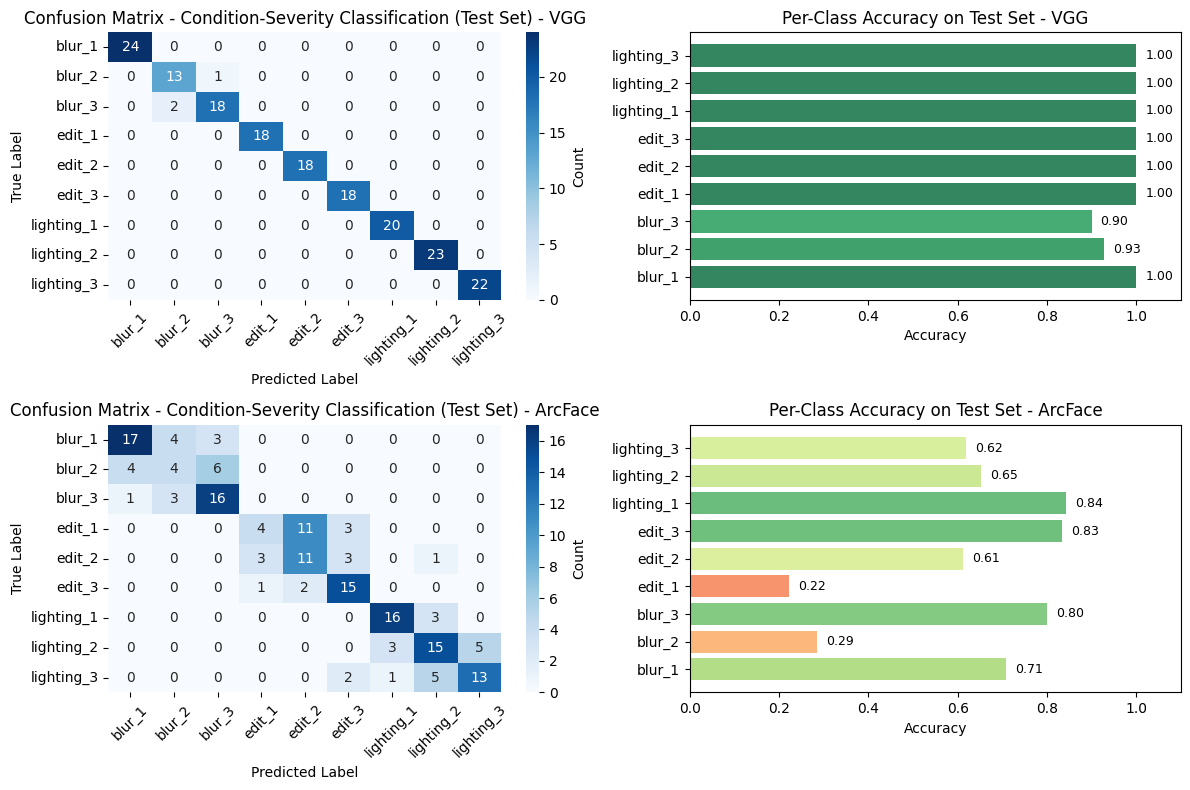

It is seen that the logistic regression model on the vgg features/data works better at identifying image conditions. Compared to the ArcFace features, the VGG features seem to have very good accuracy. This ties in to how vgg is specifically built on image classification tasks, whereas ArcFace is built for FACE recognition tasks.


In [9]:
# Compute confusion matrix -- VGG
cm_vgg = confusion_matrix(y_test_vgg, y_pred_vgg)
cm_arcface = confusion_matrix(y_test_arcface, y_pred_arcface)

# Create visualization with dynamic sizing based on number of classes
n_classes = len(condition_encoder.classes_)
fig_size = max(8, n_classes * 0.6)

fig, axes = plt.subplots(2, 2, figsize=(fig_size + 4, fig_size))
axes = axes.flatten()  # Flatten to 1D array for easier indexing

# VGG plots
# Confusion matrix - VGG
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Blues',
            xticklabels=condition_encoder.classes_,
            yticklabels=condition_encoder.classes_,
            ax=axes[0],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix - Condition-Severity Classification (Test Set) - VGG')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].tick_params(axis='x', rotation=45)

# per-class accuracy - VGG
per_class_accuracy = cm_vgg.diagonal() / cm_vgg.sum(axis=1)
colors_bar = plt.cm.RdYlGn(per_class_accuracy)
axes[1].barh(condition_encoder.classes_, per_class_accuracy, color=colors_bar, alpha=0.8)
axes[1].set_title('Per-Class Accuracy on Test Set - VGG')
axes[1].set_xlabel('Accuracy')
axes[1].set_xlim([0, 1.1])
for i, v in enumerate(per_class_accuracy):
    axes[1].text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=9)

# ARCFACE
sns.heatmap(cm_arcface, annot=True, fmt='d', cmap='Blues',
            xticklabels=condition_encoder.classes_,
            yticklabels=condition_encoder.classes_,
            ax=axes[2],
            cbar_kws={'label': 'Count'})
axes[2].set_title('Confusion Matrix - Condition-Severity Classification (Test Set) - ArcFace')
axes[2].set_ylabel('True Label')
axes[2].set_xlabel('Predicted Label')
axes[2].tick_params(axis='x', rotation=45)

# per-class accuracy - ArcFace
per_class_accuracy = cm_arcface.diagonal() / cm_arcface.sum(axis=1)
colors_bar = plt.cm.RdYlGn(per_class_accuracy)
axes[3].barh(condition_encoder.classes_, per_class_accuracy, color=colors_bar, alpha=0.8)
axes[3].set_title('Per-Class Accuracy on Test Set - ArcFace')
axes[3].set_xlabel('Accuracy')
axes[3].set_xlim([0, 1.1])
for i, v in enumerate(per_class_accuracy):
    axes[3].text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("It is seen that the logistic regression model on the vgg features/data works better at identifying image conditions. Compared to the ArcFace features, the VGG features seem to have very good accuracy. This ties in to how vgg is specifically built on image classification tasks, whereas ArcFace is built for FACE recognition tasks.")

# Finetune Re-identification Performance Based on VGG Features

In [10]:
# getting the base VGG feature performance

def evaluate_reid_performance(gallery_features, gallery_labels, probe_features, probe_labels,
                              distance_metric='euclidean', model_name='Baseline'):
    if distance_metric == 'euclidean':
        distances = euclidean_distances(probe_features, gallery_features)
    else:  # cosine
        distances = cosine_distances(probe_features, gallery_features)

    rank_1_matches = 0
    rank_5_matches = 0
    total_valid = 0

    # For each probe image, find matches in gallery
    for i, probe_label in enumerate(probe_labels):
        probe_distances = distances[i]
        # Get indices sorted by distance
        ranked_indices = np.argsort(probe_distances)

        # Check if correct person is in top-1
        if gallery_labels[ranked_indices[0]] == probe_label:
            rank_1_matches += 1

        # Check if correct person is in top-5
        if probe_label in gallery_labels[ranked_indices[:5]]:
            rank_5_matches += 1

        total_valid += 1

    rank_1_accuracy = (rank_1_matches / total_valid * 100) if total_valid > 0 else 0
    rank_5_accuracy = (rank_5_matches / total_valid * 100) if total_valid > 0 else 0

    return {
        'model': model_name,
        'rank_1': rank_1_accuracy,
        'rank_5': rank_5_accuracy,
        'distance_metric': distance_metric
    }

# Encode person labels for re-identification task
person_encoder = LabelEncoder()
vgg_gallery_labels_encoded = person_encoder.fit_transform(vgg_gallery_labels)
vgg_probe_labels_encoded = person_encoder.transform(vgg_probe_labels)

# Evaluate vanilla VGG features
vgg_baseline_euclidean = evaluate_reid_performance(
    vgg_gallery_features, vgg_gallery_labels_encoded,
    vgg_probe_features, vgg_probe_labels_encoded,
    distance_metric='euclidean',
    model_name='VGG (Vanilla - Euclidean)'
)

vgg_baseline_cosine = evaluate_reid_performance(
    vgg_gallery_features, vgg_gallery_labels_encoded,
    vgg_probe_features, vgg_probe_labels_encoded,
    distance_metric='cosine',
    model_name='VGG (Vanilla - Cosine)'
)

print("\nVanilla VGG Performance (Baseline):")
print(f"  Euclidean Distance - Rank-1: {vgg_baseline_euclidean['rank_1']:.2f}%, Rank-5: {vgg_baseline_euclidean['rank_5']:.2f}%")
print(f"  Cosine Distance   - Rank-1: {vgg_baseline_cosine['rank_1']:.2f}%, Rank-5: {vgg_baseline_cosine['rank_5']:.2f}%")


Vanilla VGG Performance (Baseline):
  Euclidean Distance - Rank-1: 52.21%, Rank-5: 81.80%
  Cosine Distance   - Rank-1: 61.90%, Rank-5: 85.88%


# Finetune the VGG Layers



In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [12]:
# gather data and index

from sklearn.preprocessing import StandardScaler, normalize

probe_indices = np.arange(len(vgg_probe_features))
train_probe_idx, test_probe_idx = train_test_split(
    probe_indices,
    test_size=0.3,
    random_state=42,
    stratify=vgg_probe_labels_encoded
)

X_train_ft = np.vstack([vgg_probe_features[train_probe_idx], vgg_gallery_features])
y_train_ft  = np.concatenate([vgg_probe_labels_encoded[train_probe_idx], vgg_gallery_labels_encoded])

X_test_probe = vgg_probe_features[test_probe_idx]
y_test_probe = vgg_probe_labels_encoded[test_probe_idx]


In [13]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transform_eval = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [19]:
from pillow_heif import register_heif_opener
register_heif_opener()

GALLERY_DIR = '/content/drive/MyDrive/GallerySet'
PROBE_DIR   = '/content/drive/MyDrive/ProbeSet'

class ReIDDataset(Dataset):
    def __init__(self, image_dir, labels, filenames, label_encoder, transform=None):
        self.image_dir     = image_dir
        self.labels        = labels
        self.filenames     = filenames
        self.label_encoder = label_encoder
        self.transform     = transform

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        person_name = self.label_encoder.classes_[self.labels[idx]]
        img_path    = os.path.join(self.image_dir, person_name, self.filenames[idx])
        image       = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

probe_train_dataset = ReIDDataset(PROBE_DIR,   vgg_probe_labels_encoded[train_probe_idx], vgg_probe_filenames[train_probe_idx], person_encoder, transform)
probe_test_dataset  = ReIDDataset(PROBE_DIR,   y_test_probe,                               vgg_probe_filenames[test_probe_idx],  person_encoder, transform_eval)
gallery_dataset     = ReIDDataset(GALLERY_DIR, vgg_gallery_labels_encoded,                 vgg_gallery_filenames,                person_encoder, transform_eval)

train_loader   = DataLoader(probe_train_dataset, batch_size=32, shuffle=True,  num_workers=2)
test_loader    = DataLoader(probe_test_dataset,  batch_size=32, shuffle=False, num_workers=2)
gallery_loader = DataLoader(gallery_dataset,     batch_size=32, shuffle=False, num_workers=2)

sample_img, sample_label = probe_train_dataset[0]
print(f"Sample image tensor shape: {sample_img.shape}, label: {sample_label}")
print(f"Train: {len(probe_train_dataset)}  Test: {len(probe_test_dataset)}  Gallery: {len(gallery_dataset)}")

Sample image tensor shape: torch.Size([3, 224, 224]), label: 10
Train: 411  Test: 177  Gallery: 134


In [20]:
class FinetunedVGG(nn.Module):
    def __init__(self, num_classes=11, embedding_dim=256):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

        # Freeze all features
        for param in vgg.features.parameters():
            param.requires_grad = False

        for param in vgg.features[24:].parameters(): # unfreeze some
            param.requires_grad = True

        # Classic VGG fine tuner stuff
        self.features  = vgg.features
        self.avgpool   = vgg.avgpool
        self.fc6_fc7   = nn.Sequential(
            vgg.classifier[0],
            vgg.classifier[1],
            vgg.classifier[2],
            vgg.classifier[3],
            vgg.classifier[4],
            vgg.classifier[5],
        )

        for param in self.fc6_fc7.parameters():
            param.requires_grad = True

        self.embedding = nn.Linear(4096, embedding_dim)
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x, return_embedding=False):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc6_fc7(x)
        emb = self.embedding(x)
        if return_embedding:
            return nn.functional.normalize(emb, p=2, dim=1)
        return self.classifier(emb)

    def forward_both(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc6_fc7(x)
        emb = self.embedding(x)
        emb_norm = nn.functional.normalize(emb, p=2, dim=1)
        logits = self.classifier(emb_norm)
        return emb_norm, logits

num_classes = len(np.unique(vgg_gallery_labels_encoded))
model = FinetunedVGG(num_classes=num_classes, embedding_dim=256).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Trainable params: 127,676,939 / 135,312,203


In [21]:
from pytorch_metric_learning import losses

ce_criterion = nn.CrossEntropyLoss()
triplet_criterion = losses.TripletMarginLoss(margin=0.2)

In [22]:
optimizer = optim.Adam([
    {'params': model.features[24:].parameters(), 'lr': 1e-6},
    {'params': model.fc6_fc7.parameters(),  'lr': 1e-5},
    {'params': model.embedding.parameters(), 'lr': 1e-3},
    {'params': model.classifier.parameters(),'lr': 1e-3},
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

EPOCHS = 10
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        embs, logits = model.forward_both(images)

        ce_loss = ce_criterion(logits, labels)
        triplet_loss = triplet_criterion(embs, labels)
        loss = ce_loss + 0.5 * triplet_loss

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += images.size(0)

    scheduler.step()
    epoch_loss = running_loss / total
    epoch_acc  = correct / total * 100
    train_losses.append(epoch_loss)
    print(f"Epoch [{epoch+1:2d}/{EPOCHS}]  Loss: {epoch_loss:.4f}  Train Acc: {epoch_acc:.1f}%")

Epoch [ 1/10]  Loss: 2.2849  Train Acc: 56.4%
Epoch [ 2/10]  Loss: 2.0147  Train Acc: 94.2%
Epoch [ 3/10]  Loss: 1.8150  Train Acc: 98.3%
Epoch [ 4/10]  Loss: 1.6669  Train Acc: 99.8%
Epoch [ 5/10]  Loss: 1.5161  Train Acc: 100.0%
Epoch [ 6/10]  Loss: 1.4106  Train Acc: 99.8%
Epoch [ 7/10]  Loss: 1.3497  Train Acc: 100.0%
Epoch [ 8/10]  Loss: 1.2983  Train Acc: 99.3%
Epoch [ 9/10]  Loss: 1.2156  Train Acc: 100.0%
Epoch [10/10]  Loss: 1.1494  Train Acc: 99.8%


In [23]:
def extract_embeddings(loader, model, device):
    model.eval()
    all_embs, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            embs   = model(images, return_embedding=True)
            all_embs.append(embs.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.vstack(all_embs), np.concatenate(all_labels)

gallery_embs_vgg2, gallery_labels_vgg2 = extract_embeddings(gallery_loader, model, device)
probe_embs_vgg2,   probe_labels_vgg2   = extract_embeddings(test_loader,    model, device)

vgg2_euclidean = evaluate_reid_performance(
    gallery_embs_vgg2, gallery_labels_vgg2,
    probe_embs_vgg2,   probe_labels_vgg2,
    distance_metric='euclidean', model_name='VGG (Finetuned Layers - Euclidean)'
)
vgg2_cosine = evaluate_reid_performance(
    gallery_embs_vgg2, gallery_labels_vgg2,
    probe_embs_vgg2,   probe_labels_vgg2,
    distance_metric='cosine', model_name='VGG (Finetuned Layers - Cosine)'
)

print(f"Finetuned VGG Layers: Euclidean Rank-1: {vgg2_euclidean['rank_1']:.2f}%  Cosine Rank-1: {vgg2_cosine['rank_1']:.2f}%")
print(f"vs baseline:       Euclidean Rank-1: {vgg_baseline_euclidean['rank_1']:.2f}%  Cosine Rank-1: {vgg_baseline_cosine['rank_1']:.2f}%")

Finetuned VGG Layers: Euclidean Rank-1: 89.27%  Cosine Rank-1: 89.27%
vs baseline:       Euclidean Rank-1: 52.21%  Cosine Rank-1: 61.90%
